# 코호트 분석 (Cohort Analysis)

## 분석 목적

고객을 첫 구매 시기별로 그룹화하고(코호트), 시간이 지나면서 각 코호트의 재구매율(retention)이 어떻게 변하는지 추적한다.

RFM 분석이 "현재 시점의 고객 가치"를 본다면, 코호트 분석은 "시간 흐름에 따른 고객 행동"을 본다.

## 분석 흐름

1. 첫 구매 월 기준으로 코호트 정의
2. 각 코호트의 월별 활동 추적
3. Retention rate 계산
4. 코호트 매트릭스 시각화 (히트맵)
5. 시즌성 및 코호트별 차이 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
from scipy import stats   
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 강제 설정 (Windows)
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

fm.fontManager.addfont(font_path)
mpl.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = font_name

sns.set_style("whitegrid", {"font.family": font_name})
plt.rcParams['figure.figsize'] = (12, 5)

# 통합 데이터셋 로드
df = pd.read_csv('../data/analysis_dataset.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print(f"적용된 폰트: {font_name}")
print(f"데이터 로드 완료: {len(df):,}행, {df['customer_unique_id'].nunique():,}명")
df.head()

적용된 폰트: Malgun Gothic
데이터 로드 완료: 96,478행, 93,358명


,order_id,customer_unique_id,order_purchase_timestamp,total_price,item_count,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,29.99,1,SP
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,118.70,1,BA
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,159.90,1,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,45.00,1,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,19.90,1,SP


## 1. 코호트 정의

각 고객의 첫 구매 월(cohort_month)을 기준으로 그룹을 만든다.

- cohort_month: 고객이 처음으로 구매한 월
- order_month: 실제 주문이 발생한 월
- cohort_index: cohort_month 기준 몇 개월 후의 구매인가

cohort_index = 0 은 첫 구매 월, 1은 그 다음 달을 의미한다.

In [2]:
# 주문 월 단위로 변환
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

# 각 고객의 첫 구매 월 (코호트 월)
df['cohort_month'] = df.groupby('customer_unique_id')['order_month'].transform('min')

# 코호트 인덱스: 첫 구매 월로부터 몇 개월 후인가
def diff_months(d2, d1):
    return (d2.dt.year - d1.dt.year) * 12 + (d2.dt.month - d1.dt.month)

df['cohort_index'] = diff_months(df['order_month'], df['cohort_month'])

print(df[['customer_unique_id', 'order_month', 'cohort_month', 'cohort_index']].head(10))
print(f"\n코호트 월 종류: {df['cohort_month'].nunique()}개")
print(f"cohort_index 범위: {df['cohort_index'].min()} ~ {df['cohort_index'].max()}")

                 customer_unique_id order_month cohort_month  cohort_index
0  7c396fd4830fd04220f754e42b4e5bff  2017-10-01   2017-09-01             1
1  af07308b275d755c9edb36a90c618231  2018-07-01   2018-07-01             0
2  3a653a41f6f9fc3d2a113cf8398680e8  2018-08-01   2018-08-01             0
3  7c142cf63193a1473d2e66489a9ae977  2017-11-01   2017-11-01             0
4  72632f0f9dd73dfee390c9b22eb56dd6  2018-02-01   2018-02-01             0
5  80bb27c7c16e8f973207a5086ab329e2  2017-07-01   2017-07-01             0
6  932afa1e708222e5821dac9cd5db4cae  2017-05-01   2017-05-01             0
7  39382392765b6dc74812866ee5ee92a7  2017-01-01   2017-01-01             0
8  299905e3934e9e181bfb2e164dd4b4f8  2017-07-01   2017-07-01             0
9  f2a85dec752b8517b5e58a06ff3cd937  2017-05-01   2017-05-01             0

코호트 월 종류: 23개
cohort_index 범위: 0 ~ 20


## 2. 코호트 매트릭스 만들기

각 셀이 "어떤 코호트(행)가 첫 구매 후 N개월(열) 시점에 활동한 고객 수"를 의미하는 매트릭스를 만든다.

In [3]:
# 코호트 매트릭스: 코호트 월 × cohort_index → 활동 고객 수
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()

cohort_matrix = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

# 코호트 크기 (각 코호트의 첫 달 고객 수)
cohort_size = cohort_matrix[0]

print("코호트 매트릭스 (고객 수)")
print(cohort_matrix.head(10))
print(f"\n코호트 크기 범위: {cohort_size.min()} ~ {cohort_size.max()}명")

코호트 매트릭스 (고객 수)
cohort_index      0     1     2     3     4     5     6    7    8     9    10  \
cohort_month                                                                    
2016-09-01       1.0   NaN   NaN   NaN   NaN   NaN   NaN  NaN  NaN   NaN  NaN   
2016-10-01     262.0   NaN   NaN   NaN   NaN   NaN   1.0  NaN  NaN   1.0  NaN   
2016-12-01       1.0   1.0   NaN   NaN   NaN   NaN   NaN  NaN  NaN   NaN  NaN   
2017-01-01     717.0   2.0   2.0   1.0   3.0   1.0   3.0  1.0  1.0   NaN  3.0   
2017-02-01    1628.0   3.0   5.0   2.0   7.0   2.0   4.0  3.0  2.0   3.0  2.0   
2017-03-01    2503.0  11.0   9.0  10.0   9.0   4.0   4.0  8.0  8.0   2.0  9.0   
2017-04-01    2256.0  14.0   5.0   4.0   6.0   6.0   8.0  7.0  7.0   4.0  6.0   
2017-05-01    3451.0  16.0  16.0  10.0  10.0  11.0  14.0  5.0  9.0   9.0  9.0   
2017-06-01    3037.0  15.0  12.0  13.0   9.0  12.0  11.0  7.0  4.0   6.0  9.0   
2017-07-01    3752.0  20.0  13.0   9.0  11.0   8.0  12.0  4.0  7.0  10.0  8.0   

cohort_inde

In [4]:
# Retention rate 계산: 각 셀을 그 코호트의 첫 달 크기로 나눔
retention = cohort_matrix.divide(cohort_size, axis=0) * 100

# 보기 좋게 인덱스 포맷팅
retention.index = retention.index.strftime('%Y-%m')

print("Retention Rate (%)")
print(retention.round(2).head(10))

Retention Rate (%)
cohort_index     0       1     2     3     4     5     6     7     8     9   \
cohort_month                                                                  
2016-09       100.0     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2016-10       100.0     NaN   NaN   NaN   NaN   NaN  0.38   NaN   NaN  0.38   
2016-12       100.0  100.00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2017-01       100.0    0.28  0.28  0.14  0.42  0.14  0.42  0.14  0.14   NaN   
2017-02       100.0    0.18  0.31  0.12  0.43  0.12  0.25  0.18  0.12  0.18   
2017-03       100.0    0.44  0.36  0.40  0.36  0.16  0.16  0.32  0.32  0.08   
2017-04       100.0    0.62  0.22  0.18  0.27  0.27  0.35  0.31  0.31  0.18   
2017-05       100.0    0.46  0.46  0.29  0.29  0.32  0.41  0.14  0.26  0.26   
2017-06       100.0    0.49  0.40  0.43  0.30  0.40  0.36  0.23  0.13  0.20   
2017-07       100.0    0.53  0.35  0.24  0.29  0.21  0.32  0.11  0.19  0.27   

cohort_index    10    11    12  

## 3. 코호트 히트맵 시각화

전형적인 코호트 분석 시각화. 각 셀의 색이 retention rate를 나타낸다.
- 좌측 첫 열은 항상 100% (첫 달은 그 코호트의 100%가 활동)
- 오른쪽으로 갈수록 색이 옅어지면 retention 감소

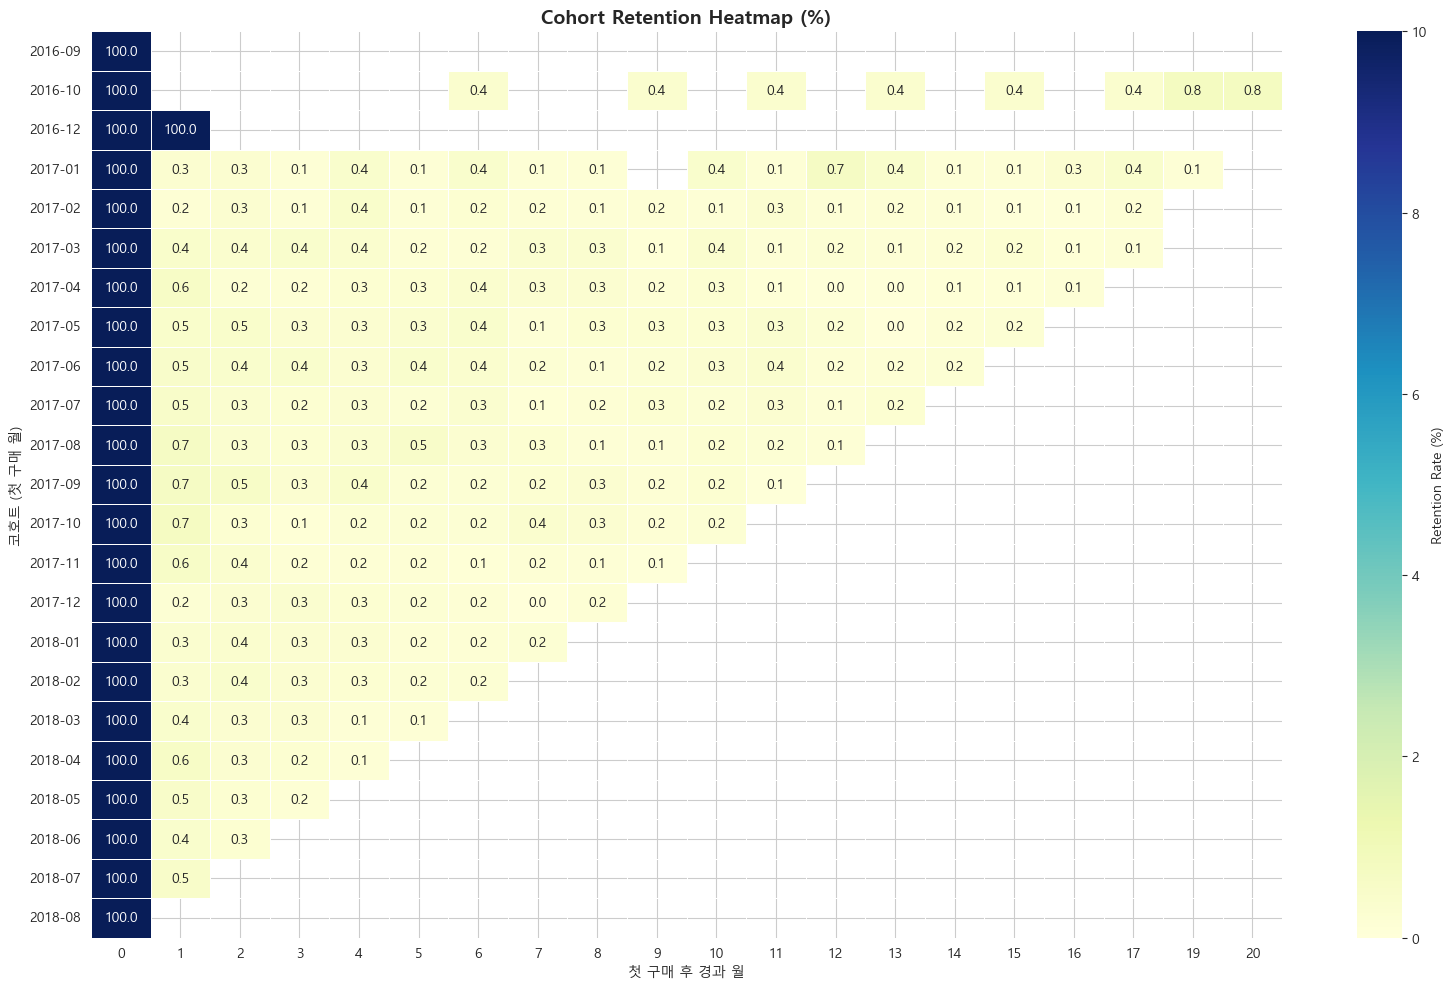

In [5]:
# 히트맵 (전체)
plt.figure(figsize=(16, 10))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5,
    vmin=0,
    vmax=10
)

plt.title('Cohort Retention Heatmap (%)', fontsize=14, fontweight='bold')
plt.xlabel('첫 구매 후 경과 월')
plt.ylabel('코호트 (첫 구매 월)')
plt.tight_layout()
plt.savefig('../images/cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

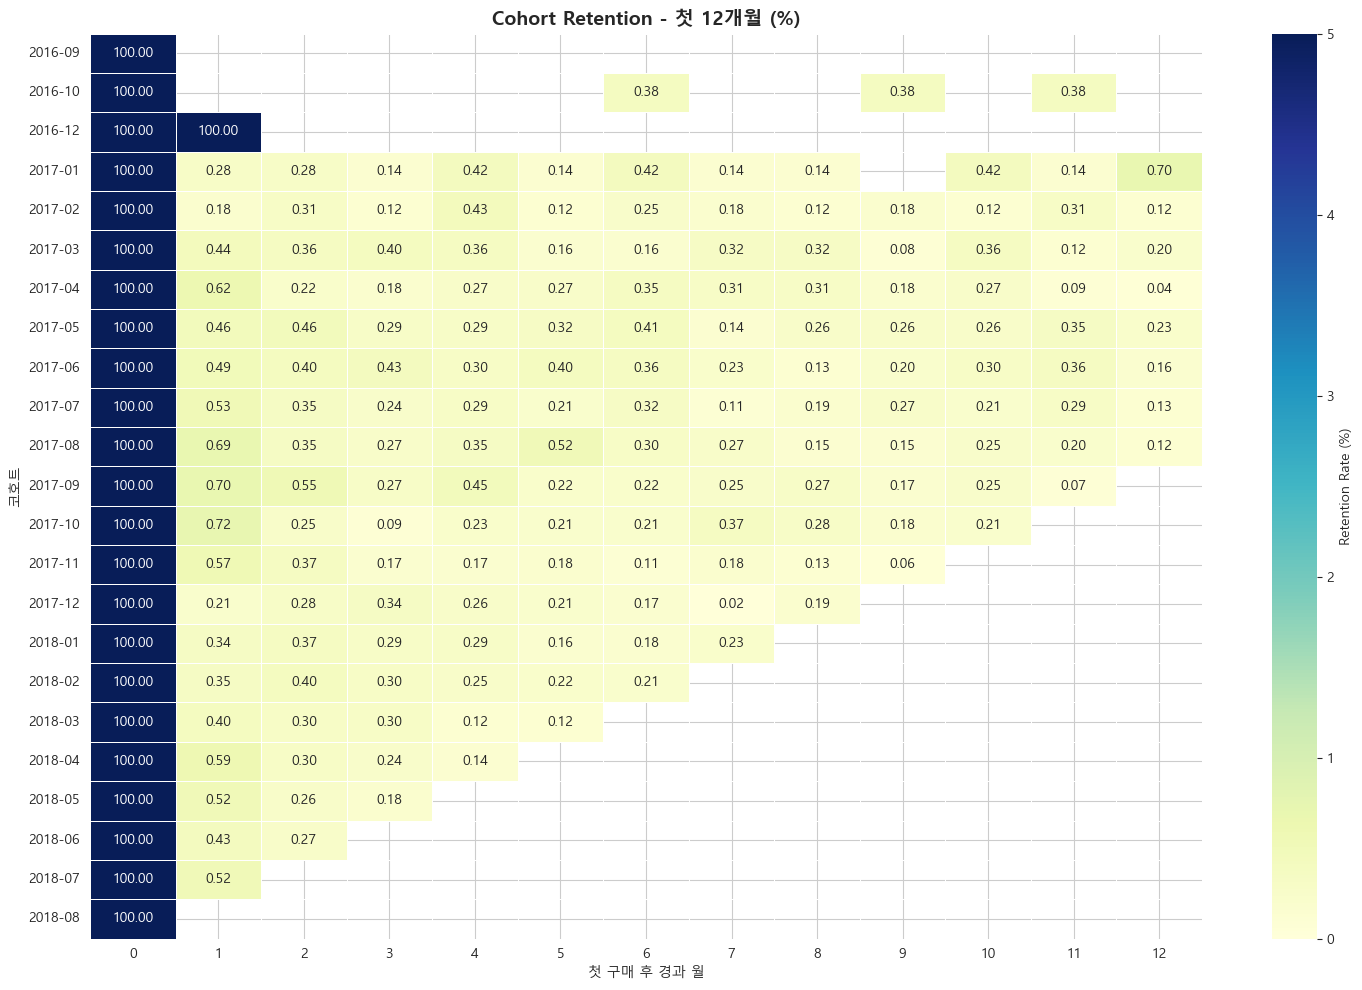

In [6]:
# 첫 12개월만 자세히 보기
retention_12 = retention.iloc[:, :13]

plt.figure(figsize=(15, 10))
sns.heatmap(
    retention_12,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5,
    vmin=0,
    vmax=5
)

plt.title('Cohort Retention - 첫 12개월 (%)', fontsize=14, fontweight='bold')
plt.xlabel('첫 구매 후 경과 월')
plt.ylabel('코호트')
plt.tight_layout()
plt.show()

## 4. Retention Curve

월별 코호트의 retention 곡선을 겹쳐 그린다.
- 모든 코호트가 비슷한 곡선을 그리면 retention 패턴이 안정적
- 특정 코호트가 다른 곡선을 그리면 그 시기에 특별한 일이 있었다는 신호

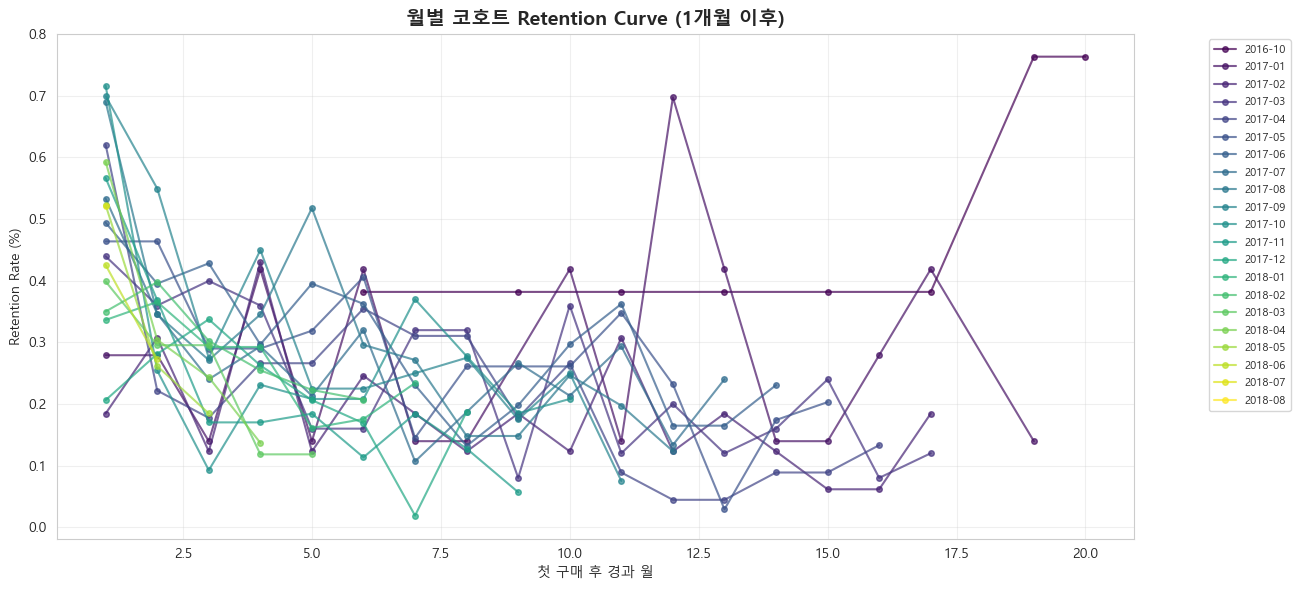

In [7]:
# Retention curve 시각화
plt.figure(figsize=(13, 6))

# 코호트 크기가 충분한 경우만 (소규모 코호트는 노이즈 큼)
significant_cohorts = cohort_size[cohort_size >= 100].index
significant_cohorts_str = significant_cohorts.strftime('%Y-%m')

# 색상 그라데이션 (시간 순서 표현)
colors = plt.cm.viridis(np.linspace(0, 1, len(significant_cohorts_str)))

for i, cohort in enumerate(significant_cohorts_str):
    if cohort in retention.index:
        values = retention.loc[cohort].dropna()
        # 첫 달(100%)은 제외하고 그리기
        plt.plot(values.index[1:], values.values[1:],
                 marker='o', markersize=4, alpha=0.7,
                 color=colors[i], label=cohort)

plt.title('월별 코호트 Retention Curve (1개월 이후)', fontsize=14, fontweight='bold')
plt.xlabel('첫 구매 후 경과 월')
plt.ylabel('Retention Rate (%)')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

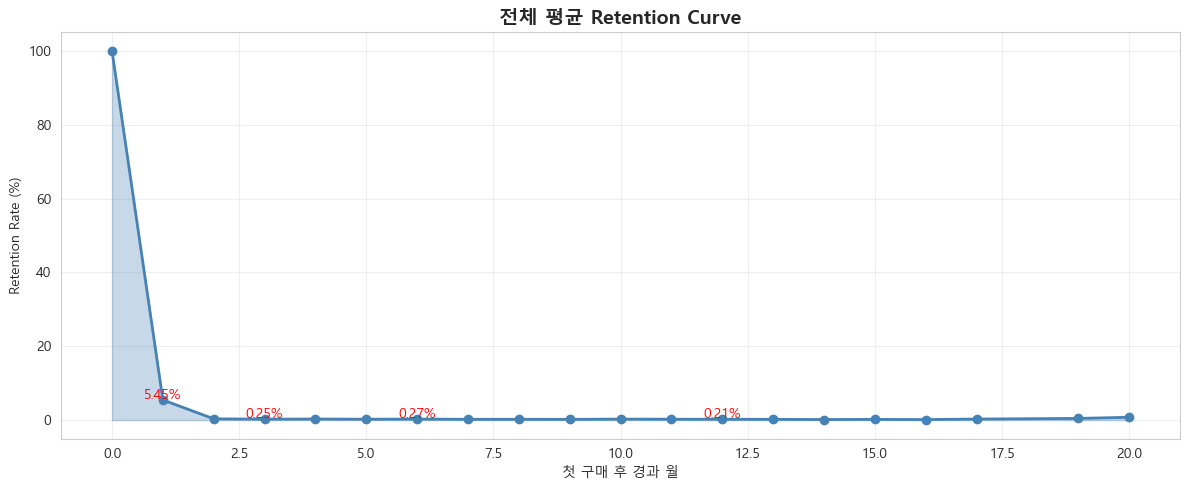


주요 시점 평균 retention:
  1개월 후: 5.45%
  3개월 후: 0.25%
  6개월 후: 0.27%
  12개월 후: 0.21%


In [8]:
# 평균 Retention curve (모든 코호트 평균)
avg_retention = retention.mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(avg_retention.index, avg_retention.values, marker='o', linewidth=2, color='steelblue')
plt.fill_between(avg_retention.index, avg_retention.values, alpha=0.3, color='steelblue')

plt.title('전체 평균 Retention Curve', fontsize=14, fontweight='bold')
plt.xlabel('첫 구매 후 경과 월')
plt.ylabel('Retention Rate (%)')
plt.grid(True, alpha=0.3)

# 주요 지점 표시
for x in [1, 3, 6, 12]:
    if x in avg_retention.index:
        y = avg_retention.loc[x]
        plt.annotate(f'{y:.2f}%',
                     xy=(x, y), xytext=(x, y + 0.3),
                     ha='center', fontsize=10, color='red')

plt.tight_layout()
plt.show()

print(f"\n주요 시점 평균 retention:")
for x in [1, 3, 6, 12]:
    if x in avg_retention.index:
        print(f"  {x}개월 후: {avg_retention.loc[x]:.2f}%")

## 5. 코호트별 1개월 Retention 비교

각 코호트의 1개월 retention을 비교해서 시기별 차이를 본다.
어떤 시기에 가입한 고객이 더 충성도가 높은지 확인할 수 있다.

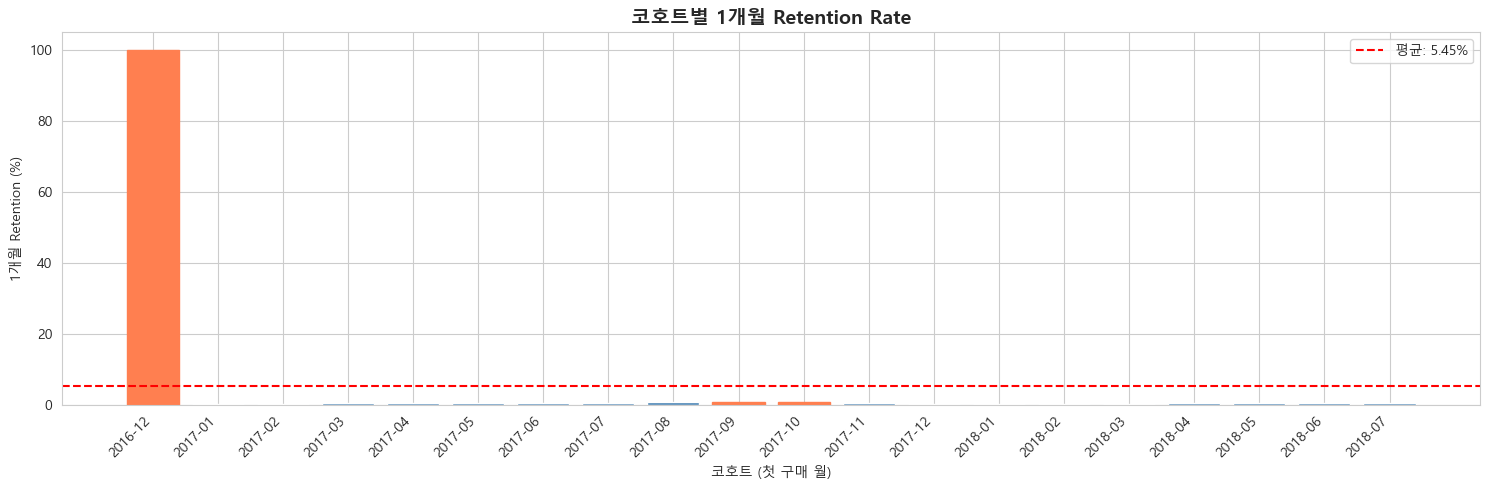


상위 3 코호트 (1개월 retention)
  2016-12: 100.00%
  2017-10: 0.72%
  2017-09: 0.70%


In [9]:
# 1개월 retention만 추출
month1_retention = retention[1].dropna()

plt.figure(figsize=(15, 5))
bars = plt.bar(range(len(month1_retention)), month1_retention.values, color='steelblue')

# 평균선
avg = month1_retention.mean()
plt.axhline(avg, color='red', linestyle='--', label=f'평균: {avg:.2f}%')

# 상위 3개 코호트 강조
top3_idx = month1_retention.values.argsort()[-3:][::-1]
for idx in top3_idx:
    bars[idx].set_color('coral')

plt.xticks(range(len(month1_retention)), month1_retention.index, rotation=45, ha='right')
plt.title('코호트별 1개월 Retention Rate', fontsize=14, fontweight='bold')
plt.xlabel('코호트 (첫 구매 월)')
plt.ylabel('1개월 Retention (%)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n상위 3 코호트 (1개월 retention)")
for idx in top3_idx:
    print(f"  {month1_retention.index[idx]}: {month1_retention.iloc[idx]:.2f}%")

In [ ]:
# 코호트 크기와 retention의 관계
plt.figure(figsize=(12, 5))

# 1개월 retention이 있는 코호트만
valid_cohorts = month1_retention.index
sizes_all = cohort_size.loc[cohort_size.index.strftime('%Y-%m').isin(valid_cohorts)]
sizes_all.index = sizes_all.index.strftime('%Y-%m')
month1_retention_all = month1_retention.copy()

# 초기 소규모 코호트 제외 (2016-09~12: 표본 극소, 통계적 의미 없음)
exclude_cohorts = ['2016-09', '2016-10', '2016-12']
mask = ~sizes_all.index.isin(exclude_cohorts)
sizes_filtered = sizes_all[mask]
month1_retention_filtered = month1_retention_all[month1_retention_all.index.isin(sizes_filtered.index)]

plt.scatter(sizes_filtered.values, month1_retention_filtered.values, s=80, alpha=0.6, color='steelblue')

for cohort in month1_retention_filtered.index:
    if cohort in sizes_filtered.index:
        plt.annotate(cohort,
                     (sizes_filtered.loc[cohort], month1_retention_filtered.loc[cohort]),
                     fontsize=7, alpha=0.7)

plt.xlabel('코호트 크기 (첫 달 고객 수)')
plt.ylabel('1개월 Retention (%)')
plt.title('코호트 크기 vs Retention (2017-01 이후)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/cohort_size_vs_retention.png', dpi=150, bbox_inches='tight')
plt.show()

# === 이상치 민감도 검증 (Sensitivity Check) ===
print("=" * 60)
print("이상치 민감도 검증 (Sensitivity Check)")
print("=" * 60)

# 1) 전체 코호트 (이상치 포함)
r_all, p_all = stats.pearsonr(sizes_all.values, month1_retention_all.values)
print(f"\n전체 코호트 (n={len(sizes_all)}):")
print(f"  Pearson r = {r_all:.3f}, p = {p_all:.4f}")

# 2) 초기 소규모 코호트 제외
r_filtered, p_filtered = stats.pearsonr(sizes_filtered.values, month1_retention_filtered.values)
print(f"\n2016년 초기 코호트 제외 (n={len(sizes_filtered)}):")
print(f"  Pearson r = {r_filtered:.3f}, p = {p_filtered:.4f}")

print(f"\n결론:")
print(f"  전체 데이터의 음의 상관(r={r_all:.3f})은")
print(f"  2016-12 코호트(1명, retention 100%)에 의해 과대 추정됨.")
print(f"  이상치 제외 시 상관관계 소멸(r={r_filtered:.3f}, p={p_filtered:.3f}).")
print(f"  → 코호트 크기와 retention의 관계는 본 데이터에서 확인되지 않음.")

## 6. 결론

### 핵심 발견

**1. Brazilian 이커머스의 retention은 극도로 낮음**
- 1개월 retention: 5.45%
- 3개월 retention: 0.25%
- 6개월 retention: 0.27%
- 12개월 retention: 0.21%

**2. 첫 30일이 retention의 결정적 시기**
- 1개월 retention(5.45%)이 그 이후 시점(0.2~0.3%)보다 약 20배 높음
- 재구매 의사결정이 사실상 첫 달 안에 끝남
- 첫 달 이후의 marginal retention은 거의 0에 수렴

**3. 코호트 크기와 retention의 상관관계: 이상치 민감도 검증**

| 조건 | n | Pearson r | p-value | 해석 |
|------|---|-----------|---------|------|
| 전체 코호트 | 20 | -0.472 | 0.036 | 유의 (α=0.05) |
| 2016년 초기 코호트 제외 | 17 | 0.115 | 0.640 | 유의하지 않음 |

- 전체 데이터에서 관찰된 음의 상관(r=-0.472)은 2016-12 코호트(1명, retention 100%)에 의해 과대 추정
- 이상치 제외 시 상관관계가 완전히 소멸 (r=0.115)
- **결론**: 본 데이터에서 "코호트가 클수록 retention이 낮다"는 가설은 지지되지 않음
- **학습**: 소규모 표본에서 이상치 1개가 상관 분석 결과를 얼마나 왜곡할 수 있는지의 사례

**4. 상위 retention 코호트**
- 2017-10: 0.72%
- 2017-09: 0.70%
- (2016-12는 코호트 크기 1명이라 통계적 의미 없음, 제외)

### 비즈니스 시사점

- 첫 구매 후 30일 내 재구매 유도 캠페인이 최대 레버리지
- 신규 고객 획득 비용 vs 첫 30일 재구매 유도 비용 비교 분석 필요
- 대규모 프로모션 의존 전략의 retention 비용 검토 필요

### 분석의 한계

- 2년치 데이터로 12개월 이상 retention은 일부 코호트만 관측됨
- 2016년 9~12월 코호트는 표본이 매우 작아 통계적 의미가 떨어짐
- 외부 변수(마케팅 캠페인 시점, 프로모션 등) 미반영
- 카테고리/지역별 세분화는 추후 분석 과제
- 3개월 → 6개월 시점의 retention 소폭 상승은 표본 부족에 따른 노이즈 가능성